# Carregando logs de predição

In [1]:
import json
import os
from pathlib import Path
import pickle 

In [2]:
# RESULTS_DIR = Path("/exp_local/kenzosaki/data/iptc/results/")
# LABELS_DIR = Path("/exp_local/kenzosaki/data/iptc/labels/")
# GRAPH_DIR = Path("/exp_local/kenzosaki/data/iptc/graphs/")

# RESULTS_DIR = Path("/exp_local/kenzosaki/data/iptc/gemma3_27B/results/")
# LABELS_DIR = Path("/exp_local/kenzosaki/data/iptc/gemma3_27B/labels/")
# GRAPH_DIR = Path("/exp_local/kenzosaki/data/iptc/gemma3_27B/graphs/")

# RESULTS_DIR = Path("/exp_local/kenzosaki/data/iptc/results_temp_incorr/")
RESULTS_DIR = Path("/exp_local/kenzosaki/data/iptc/results/")
LABELS_DIR = Path("/exp_local/kenzosaki/data/iptc/labels/")
GRAPH_DIR = Path("/exp_local/kenzosaki/data/iptc/graphs/")


In [3]:
SAVE_FIGS = True

In [4]:
def attempt_to_fix_json(json_str: str) -> dict | None:
    if json_str.endswith('true') or json_str.endswith('false'):
        json_str = json_str + "}"
    
    try:
        return json.loads(json_str)
    except json.JSONDecodeError:
        return None

def fix_llama_outputs(raw_outputs: list[dict]) -> list[dict]:

    for output in raw_outputs:
        # ignorar respostas que tiveram parsing correto
        if output["success"]: continue
        
        raw_response = output["raw_response"]
        fixed_response = attempt_to_fix_json(raw_response)
        
        # se a resposta conseguiu ser corrigida, atualizar campos
        if fixed_response is not None:
            output["explanation"] = fixed_response["explanation"]
            output["link"] = fixed_response["link"]
            output["success"] = True
    
    return raw_outputs

In [5]:
raw_results = []
# carregando resultados disponiveis
for file in RESULTS_DIR.rglob("*_results.json"):
    model_name = file.parent.name
    theme = file.stem.split("_results")[0]
    
    raw_results.append(
        {
            "model_name": model_name,
            "theme": theme,
            "results": json.load(open(file))
        }
    )
# carregando labels
for log in raw_results:
    theme = log["theme"]
    log["labels_info"] = json.load(open(LABELS_DIR / f"{theme}_labels.json"))

In [6]:
# carregando grafos
graphs = {}
for file in GRAPH_DIR.rglob("*.pkl"):
    theme = file.stem.split("_")[0]
    with open(file, "rb") as f:
        graphs[theme] = pickle.load(f)

# Avaliando classificação

In [7]:
from sklearn.metrics import classification_report
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore") # ignorando warnings das metricas

In [8]:
edges_of_interest = {
    "positive_easy_edges": "easy true edge (above 75th percentile similarity)",
    "positive_hard_edges": "hard true edge (below 25th percentile similarity)",
    "negative_hard_semantic_similar_edges": "hard semantic negative",
    "negative_temporal_plausible_edges": "temporal plausible negative",
    "negative_random_edges": "random negative"
}

model_sizes_map = {
    "gemma4_E2B": 2,
    "gemma4_E4B": 4,
    "gemma4_26B": 26,
    "gemma4_31B": 31,
    "smollm2_1.7B": 1.7,
    "llama3.2_1B": 1,
    "llama3.2_3B": 3,
    "phi4_mini": 3.8,
    "qwen3_1.7B": 1.7,
    "qwen3_4B": 4,
}

In [9]:
dummy_report = classification_report([0, 0], [1, 1], output_dict=True)
dummy_report

{'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 2.0},
 '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
 'accuracy': 0.0,
 'macro avg': {'precision': 0.0,
  'recall': 0.0,
  'f1-score': 0.0,
  'support': 2.0},
 'weighted avg': {'precision': 0.0,
  'recall': 0.0,
  'f1-score': 0.0,
  'support': 2.0}}

In [10]:
results_summary = []
for res in raw_results:
    model_name = res["model_name"]
    theme = res["theme"]
    model_outputs = res["results"]
    label_info = res["labels_info"]
    all_labels = model_outputs["labels"]
    raw_outputs = model_outputs["outputs"]

    # modelos llama tem um erro recorrente -> esquecem o ultimo '}' do json, o que causa erros de parsing. A função fix_llama_outputs tenta corrigir isso.
    if "llama3.2" in model_name:
        raw_outputs = fix_llama_outputs(raw_outputs)

    valid_outputs = [o for o in raw_outputs if o["success"]]
    valid_label_info = [label_info for label_info, out in zip(label_info, raw_outputs) if out["success"]]

    # taxa de resposta valida (segue o formato esperado, sem erros de parsing)
    success_rate = len(valid_outputs) / len(raw_outputs)

    # performance geral
    valid_labels = [label_info["label"] for label_info in valid_label_info]

    preds = [out["link"] for out in valid_outputs]
    
    if success_rate > 0:
        report_dict = classification_report(valid_labels, preds, output_dict=True)
    else:
        report_dict = dummy_report
    
    results_summary.append(
        {
            "model_name": model_name,
            "B_params": model_sizes_map.get(model_name, None),
            "theme": theme,
            "edges": "all",
            "success_rate": success_rate,
            "accuracy": report_dict["accuracy"],
            "precision": report_dict["macro avg"]["precision"],
            "recall": report_dict["macro avg"]["recall"],
            "f1-score": report_dict["macro avg"]["f1-score"],
            "support": report_dict["macro avg"]["support"],
        }
    )

    # performance por tipo de edge
    for edge_key, edge_desc in edges_of_interest.items():
        edge_labels = [label_info["label"] for label_info in valid_label_info if label_info["label_description"] == edge_desc]
        edge_preds = [out["link"] for out, label_info in zip(valid_outputs, valid_label_info) if label_info["label_description"] == edge_desc]
        
        if success_rate > 0:
            edge_report_dict = classification_report(edge_labels, edge_preds, output_dict=True)
        else:
            edge_report_dict = dummy_report

        results_summary.append(
            {
                "model_name": model_name,
                "B_params": model_sizes_map.get(model_name, None),
                "theme": theme,
                "edges": edge_key,
                "success_rate": success_rate,
                "accuracy": edge_report_dict["accuracy"],
                "precision": edge_report_dict["macro avg"]["precision"],
                "recall": edge_report_dict["macro avg"]["recall"],
                "f1-score": edge_report_dict["macro avg"]["f1-score"],
                "support": edge_report_dict["macro avg"]["support"],
            }
        )
        

In [11]:
results_df = pd.DataFrame(results_summary)

In [12]:
# verificando status dos resultados
results_df[results_df["edges"] == "all"]["model_name"].value_counts()

model_name
qwen3_1.7B      15
smollm2_1.7B    15
gemma4_E2B      15
llama3.2_3B     15
gemma4_26B      15
phi4_mini       15
llama3.2_1B     15
qwen3_4B        15
gemma4_E4B      15
Name: count, dtype: int64

In [13]:
# removendo tinyllama
results_df = results_df[~results_df['model_name'].str.contains("tiny")]

In [14]:
# melhorando nomes de modelos
results_df["model_name"] = results_df["model_name"].apply(lambda x: " ".join([word.capitalize() for word in x.split("_")]))
results_df["model_name"] = results_df["model_name"].apply(lambda x: x[:-1] + "B" if x.endswith("b") else x) # padronizando tamanhos dos modelos

In [15]:
# serializando resultados
results_df.to_csv("../data/link_prediction_results_summary.csv", decimal=",")

## Todas as arestas
- tendência geral: modelos maiores apresentam as maiores métricas.
- com exceção dos modelos da família llama, todos os modelos tiveram taxas de sucesso (geração de JSON de resposta válido) acima de 99%.
- os modelos llama curiosamente tiveram a tendência de esquecer de fechar um "}" nas suas saídas.
- na maioria dos grafos/temas avaliado, o modelo que apresenta as maiores métricas é o gemma4-E4B.
- destaque para o modelo gemma4 de 2B entregando performance superior a um modelo com o dobro de parâmetros.
- quanto maiores os modelos, maior desvio padrão ao considerar o F1 em todos os 15 grafos.

In [16]:
# gemmas
gemma_mask = results_df["model_name"].str.contains("gemma")
results_df[(results_df["edges"] == "all") & gemma_mask].sort_values(["theme", "model_name"], ascending=True)

,model_name,B_params,theme,edges,success_rate,accuracy,precision,recall,f1-score,support


In [17]:
# resultados agregados para todos os 15 temas
edges = "all"
res = results_df[results_df["edges"] == edges].groupby("model_name").agg(
    #B_params_mean = ("B_params", "mean"),
    acc_mean = ("accuracy", "mean"),
    acc_std = ("accuracy", "std"),
    prec_mean = ("precision", "mean"),
    prec_std = ("precision", "std"),
    rec_mean = ("recall", "mean"),
    rec_std = ("recall", "std"),
    f1_mean = ("f1-score", "mean"),
    f1_std = ("f1-score", "std"),
    #success_rate_mean = ("success_rate", "mean"),
).sort_values("f1_mean", ascending=False)
res

,acc_mean,acc_std,prec_mean,prec_std,rec_mean,rec_std,f1_mean,f1_std
model_name,,,,,,,,
Gemma4 E4B,0.628734,0.057246,0.656721,0.051780,0.628642,0.057196,0.607148,0.072115
Phi4 Mini,0.605297,0.041827,0.614632,0.041698,0.605299,0.041832,0.595995,0.047108
Gemma4 26B,0.624535,0.065364,0.664480,0.060962,0.624442,0.065399,0.593997,0.084204
Gemma4 E2B,0.598045,0.058337,0.616351,0.055885,0.598036,0.058324,0.576933,0.071220
Llama3.2 3B,0.577235,0.033728,0.582281,0.035851,0.577207,0.033779,0.570432,0.036829
Qwen3 4B,0.585980,0.047194,0.662453,0.046833,0.585969,0.047208,0.525046,0.069497
Llama3.2 1B,0.523953,0.022682,0.524774,0.023394,0.523981,0.022679,0.521016,0.022297
Qwen3 1.7B,0.551341,0.032189,0.622643,0.040108,0.551279,0.032179,0.470535,0.056653
Smollm2 1.7B,0.509247,0.007206,0.556764,0.038601,0.509366,0.006885,0.380480,0.022796


In [18]:
# tentando facilitar minha vida. vai virar func depois
# formatando precisao
metrics_prefix_map = {
    "Accuracy": "acc",
    "Precision": "prec",
    "Recall": "rec",
    "F1": "f1"
}

inter_df = res.copy()
for col in inter_df.columns:
    inter_df[col] = inter_df[col].apply(lambda x: f"{x:.3f}")

# criando tabela
inter_df = inter_df.reset_index()
table_df = pd.DataFrame()
table_df["Model"] = inter_df["model_name"]

for metric, prefix in metrics_prefix_map.items():
    table_df[metric] = "$" + inter_df[prefix + "_mean"]
    table_df[metric] += " \pm "
    table_df[metric] += inter_df[prefix + "_std"] + "$"
    
print(table_df.to_latex(index=False, column_format="lcccc"))

\begin{tabular}{lcccc}
\toprule
Model & Accuracy & Precision & Recall & F1 \\
\midrule
Gemma4 E4B & $0.629 \pm 0.057$ & $0.657 \pm 0.052$ & $0.629 \pm 0.057$ & $0.607 \pm 0.072$ \\
Phi4 Mini & $0.605 \pm 0.042$ & $0.615 \pm 0.042$ & $0.605 \pm 0.042$ & $0.596 \pm 0.047$ \\
Gemma4 26B & $0.625 \pm 0.065$ & $0.664 \pm 0.061$ & $0.624 \pm 0.065$ & $0.594 \pm 0.084$ \\
Gemma4 E2B & $0.598 \pm 0.058$ & $0.616 \pm 0.056$ & $0.598 \pm 0.058$ & $0.577 \pm 0.071$ \\
Llama3.2 3B & $0.577 \pm 0.034$ & $0.582 \pm 0.036$ & $0.577 \pm 0.034$ & $0.570 \pm 0.037$ \\
Qwen3 4B & $0.586 \pm 0.047$ & $0.662 \pm 0.047$ & $0.586 \pm 0.047$ & $0.525 \pm 0.069$ \\
Llama3.2 1B & $0.524 \pm 0.023$ & $0.525 \pm 0.023$ & $0.524 \pm 0.023$ & $0.521 \pm 0.022$ \\
Qwen3 1.7B & $0.551 \pm 0.032$ & $0.623 \pm 0.040$ & $0.551 \pm 0.032$ & $0.471 \pm 0.057$ \\
Smollm2 1.7B & $0.509 \pm 0.007$ & $0.557 \pm 0.039$ & $0.509 \pm 0.007$ & $0.380 \pm 0.023$ \\
\bottomrule
\end{tabular}



In [19]:
# melhor modelo por grafo
all_edges_df = results_df[results_df["edges"] == edges]

all_edges_df.groupby("theme").apply(lambda group: group.sort_values("f1-score", ascending=False).head(1))

,,model_name,B_params,theme,edges,success_rate,accuracy,precision,recall,f1-score,support
theme,,,,,,,,,,,
conflict,720,Gemma4 E4B,4.0,conflict,all,1.000000,0.657427,0.659515,0.657450,0.656322,2417.0
crime,306,Llama3.2 3B,3.0,crime,all,0.999608,0.553333,0.554319,0.553359,0.551363,5100.0
cybersecurity,774,Gemma4 E4B,4.0,cybersecurity,all,0.999363,0.680153,0.708385,0.679977,0.668807,3139.0
disaster,516,Phi4 Mini,3.8,disaster,all,1.000000,0.606436,0.639809,0.606508,0.581549,3387.0
economy,762,Gemma4 E4B,4.0,economy,all,0.998606,0.637560,0.653701,0.637430,0.627658,5016.0
education,510,Phi4 Mini,3.8,education,all,1.000000,0.544767,0.550513,0.544767,0.531441,4892.0
energy,804,Gemma4 E4B,4.0,energy,all,0.999354,0.620690,0.641474,0.620607,0.606134,4640.0
environment,798,Gemma4 E4B,4.0,environment,all,0.996237,0.629839,0.657050,0.629444,0.612664,4236.0
health,522,Phi4 Mini,3.8,health,all,1.000000,0.655933,0.659671,0.655916,0.653893,4441.0


In [20]:
all_diffs = all_edges_df["precision"] - all_edges_df["recall"]
prec_is_higher = all_edges_df["precision"] > all_edges_df["recall"]
recall_is_higher = ~prec_is_higher
median_prec_improv = all_diffs[prec_is_higher].median()
median_recall_improv = all_diffs[recall_is_higher].median()
total = len(all_edges_df)
print(f"- Precision is higher in {prec_is_higher.sum()/total * 100 :.3f}% of the evaluations (more false negatives than false positives).")
print(f"\t- median improvement {median_prec_improv:.3f}")
print(f"- Recall is higher in {recall_is_higher.sum()/total * 100 :.3f}% of the evaluations (more false positives than false negatives).")
print(f"\t- median improvement {median_recall_improv:.3f}")

- Precision is higher in 97.778% of the evaluations (more false negatives than false positives).
	- median improvement 0.026
- Recall is higher in 2.222% of the evaluations (more false positives than false negatives).
	- median improvement -0.000


<Axes: xlabel='f1-score', ylabel='model_name'>

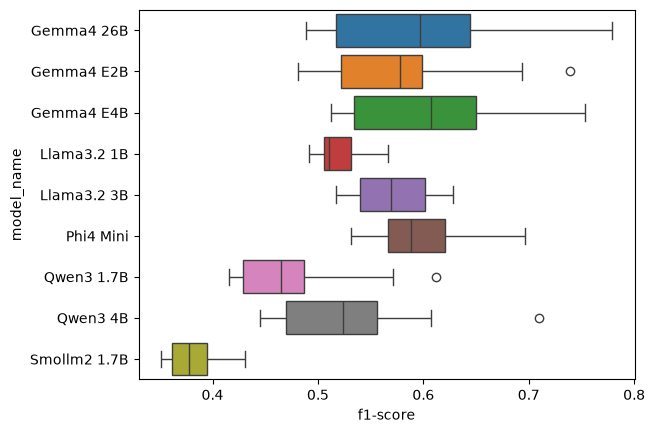

In [21]:
sns.boxplot(data=all_edges_df.sort_values(by="model_name"), x="f1-score", y="model_name", hue="model_name")

## Arestas positivas fáceis (similaridade acima do 3o quartil das similaridades das arestas de teste)
- no geral, métricas altas para todos os modelos. Ou seja, este é um grupo de arestas fácil de classificar.
- dois modelos se destacaram neste grupo de arestas: smollm, phi4 mini llama3.2 - 3B. Isto nos leva a entender que eles exploram mais a similaridade semântica para predizer links do que os outros modelos.

In [22]:
edges = "positive_easy_edges"

In [23]:
easy_pos_edges_df = results_df[results_df["edges"] == edges].groupby("model_name").agg(
    #B_params_mean = ("B_params", "mean"),
    acc_mean = ("accuracy", "mean"),
    acc_std = ("accuracy", "std"),
    prec_mean = ("precision", "mean"),
    prec_std = ("precision", "std"),
    rec_mean = ("recall", "mean"),
    rec_std = ("recall", "std"),
    f1_mean = ("f1-score", "mean"),
    f1_std = ("f1-score", "std"),
    #success_rate_mean = ("success_rate", "mean"),
).sort_values("acc_mean", ascending=False)
easy_pos_edges_df

,acc_mean,acc_std,prec_mean,prec_std,rec_mean,rec_std,f1_mean,f1_std
model_name,,,,,,,,
Smollm2 1.7B,0.983271,0.010391,0.5,0.0,0.491635,0.005195,0.495769,0.002654
Phi4 Mini,0.765032,0.115759,0.5,0.0,0.382516,0.057880,0.431157,0.037350
Llama3.2 3B,0.739960,0.106689,0.5,0.0,0.369980,0.053345,0.423208,0.036175
Llama3.2 1B,0.706565,0.068920,0.5,0.0,0.353283,0.034460,0.413086,0.025043
Gemma4 E2B,0.686512,0.121755,0.5,0.0,0.343256,0.060877,0.404156,0.043222
Gemma4 E4B,0.679916,0.116078,0.5,0.0,0.339958,0.058039,0.401987,0.042666
Gemma4 26B,0.655868,0.141596,0.5,0.0,0.327934,0.070798,0.391968,0.051740
Qwen3 4B,0.450078,0.113128,0.5,0.0,0.225039,0.056564,0.306671,0.051147
Qwen3 1.7B,0.336343,0.102374,0.5,0.0,0.168171,0.051187,0.247833,0.054126


<Axes: xlabel='f1-score', ylabel='model_name'>

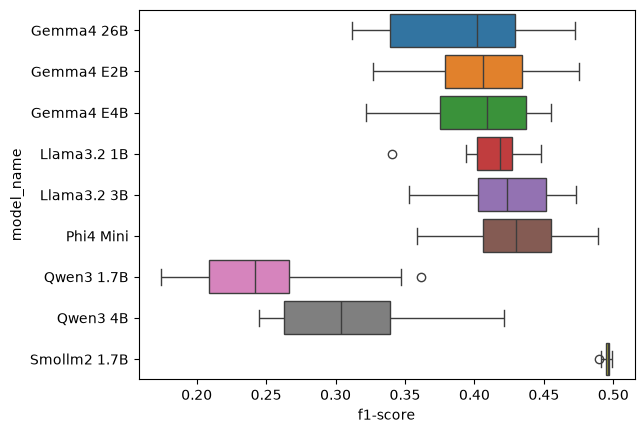

In [24]:
sns.boxplot(data=results_df[results_df["edges"] == edges].sort_values(by="model_name"), x="f1-score", y="model_name", hue="model_name")

## Arestas positivas difíceis (similaridade abaixo do 1o quartil das similaridades das arestas de teste)
- novamente o modelo smollm se destaca, com métricas muito superiores aos demais.

In [25]:
edges = "positive_hard_edges"

In [26]:
positive_hard_edges_df = results_df[results_df["edges"] == edges].groupby("model_name").agg(
    #B_params_mean = ("B_params", "mean"),
    acc_mean = ("accuracy", "mean"),
    acc_std = ("accuracy", "std"),
    prec_mean = ("precision", "mean"),
    prec_std = ("precision", "std"),
    rec_mean = ("recall", "mean"),
    rec_std = ("recall", "std"),
    f1_mean = ("f1-score", "mean"),
    f1_std = ("f1-score", "std"),
    #success_rate_mean = ("success_rate", "mean"),
).sort_values("acc_mean", ascending=False)
positive_hard_edges_df

,acc_mean,acc_std,prec_mean,prec_std,rec_mean,rec_std,f1_mean,f1_std
model_name,,,,,,,,
Smollm2 1.7B,0.941367,0.036563,0.5,0.0,0.470683,0.018282,0.484725,0.009900
Llama3.2 1B,0.405575,0.107059,0.5,0.0,0.202788,0.053529,0.284838,0.052273
Llama3.2 3B,0.315765,0.132098,0.5,0.0,0.157882,0.066049,0.233118,0.073645
Phi4 Mini,0.285837,0.128588,0.5,0.0,0.142918,0.064294,0.215405,0.074087
Gemma4 E4B,0.186089,0.101120,0.5,0.0,0.093044,0.050560,0.151262,0.070946
Gemma4 E2B,0.159854,0.095238,0.5,0.0,0.079927,0.047619,0.132638,0.067843
Gemma4 26B,0.148865,0.100155,0.5,0.0,0.074433,0.050077,0.123819,0.071034
Qwen3 4B,0.076906,0.058561,0.5,0.0,0.038453,0.029280,0.069080,0.046115
Qwen3 1.7B,0.050120,0.041210,0.5,0.0,0.025060,0.020605,0.046432,0.035402


<Axes: xlabel='f1-score', ylabel='model_name'>

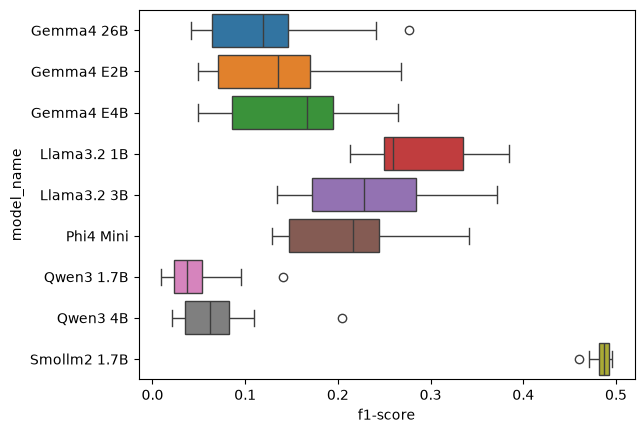

In [27]:
sns.boxplot(data=results_df[results_df["edges"] == edges].sort_values(by="model_name"), x="f1-score", y="model_name", hue="model_name")

## Arestas negativas difíceis (alta similaridade)
- os modelos destaque anteriormente (smollm e llama 3.2) foram os piores neste grupo de arestas.
- explorar muito as noções de similaridade textual não é benéfico para este conjunto da tarefa.
- por outro lado, a maioria dos modelos teve desempenhos ruim para este grupo.
- modelos da família qwen foram os melhores.

In [28]:
edges = "negative_hard_semantic_similar_edges"

In [29]:
negative_hard_edges_df = results_df[results_df["edges"] == edges].groupby("model_name").agg(
    #B_params_mean = ("B_params", "mean"),
    acc_mean = ("accuracy", "mean"),
    acc_std = ("accuracy", "std"),
    prec_mean = ("precision", "mean"),
    prec_std = ("precision", "std"),
    rec_mean = ("recall", "mean"),
    rec_std = ("recall", "std"),
    f1_mean = ("f1-score", "mean"),
    f1_std = ("f1-score", "std"),
    #success_rate_mean = ("success_rate", "mean"),
).sort_values("acc_mean", ascending=False)
negative_hard_edges_df

,acc_mean,acc_std,prec_mean,prec_std,rec_mean,rec_std,f1_mean,f1_std
model_name,,,,,,,,
Qwen3 4B,0.850084,0.047222,0.5,0.0,0.425042,0.023611,0.459161,0.013572
Qwen3 1.7B,0.849254,0.059113,0.5,0.0,0.424627,0.029556,0.458727,0.017264
Gemma4 26B,0.713764,0.106636,0.5,0.0,0.356882,0.053318,0.414321,0.037496
Gemma4 E4B,0.651618,0.100183,0.5,0.0,0.325809,0.050092,0.392520,0.035661
Gemma4 E2B,0.534974,0.130251,0.5,0.0,0.267487,0.065125,0.344212,0.054687
Phi4 Mini,0.383382,0.161642,0.5,0.0,0.191691,0.080821,0.267851,0.085777
Llama3.2 1B,0.310145,0.055519,0.5,0.0,0.155073,0.027759,0.235429,0.032827
Llama3.2 3B,0.307228,0.135346,0.5,0.0,0.153614,0.067673,0.227775,0.075377
Smollm2 1.7B,0.017985,0.012920,0.5,0.0,0.008993,0.006460,0.017521,0.012396


<Axes: xlabel='f1-score', ylabel='model_name'>

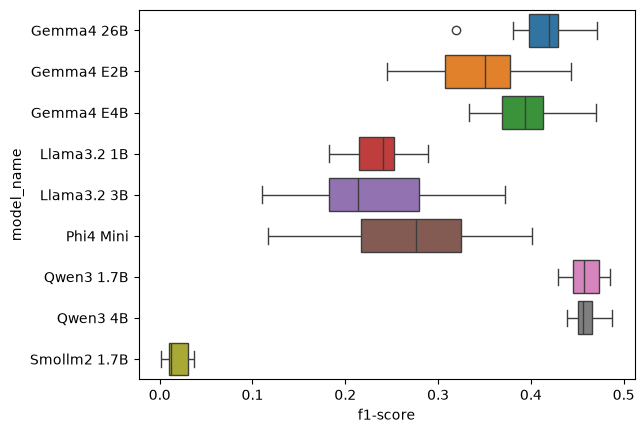

In [30]:
sns.boxplot(data=results_df[results_df["edges"] == edges].sort_values(by="model_name"), x="f1-score", y="model_name", hue="model_name")

## Arestas negativas temporalmente plausíveis
- no geral, os modelos tiveram facilidade em discriminar exemplos deste grupo.
- smollm e llama3.2-1B tiveram as piores métricas. Possívelmente por contar muito com a similaridade semântica.

In [31]:
edges = "negative_temporal_plausible_edges"

In [32]:
negative_temporal_plausible_df = results_df[results_df["edges"] == edges].groupby("model_name").agg(
    #B_params_mean = ("B_params", "mean"),
    acc_mean = ("accuracy", "mean"),
    acc_std = ("accuracy", "std"),
    prec_mean = ("precision", "mean"),
    prec_std = ("precision", "std"),
    rec_mean = ("recall", "mean"),
    rec_std = ("recall", "std"),
    f1_mean = ("f1-score", "mean"),
    f1_std = ("f1-score", "std"),
    #success_rate_mean = ("success_rate", "mean"),
).sort_values("acc_mean", ascending=False)
negative_temporal_plausible_df

,acc_mean,acc_std,prec_mean,prec_std,rec_mean,rec_std,f1_mean,f1_std
model_name,,,,,,,,
Qwen3 1.7B,0.985637,0.017761,0.566667,0.175933,0.559485,0.179045,0.563012,0.177470
Qwen3 4B,0.982453,0.019044,0.533333,0.129099,0.524560,0.131848,0.528864,0.130423
Gemma4 26B,0.961437,0.051866,0.533333,0.129099,0.514052,0.136808,0.523150,0.132659
Gemma4 E2B,0.954855,0.040941,0.500000,0.000000,0.477428,0.020470,0.488237,0.011041
Gemma4 E4B,0.944413,0.058014,0.500000,0.000000,0.472207,0.029007,0.485257,0.016140
Phi4 Mini,0.880410,0.101594,0.500000,0.000000,0.440205,0.050797,0.466608,0.031638
Llama3.2 3B,0.815650,0.098472,0.500000,0.000000,0.407825,0.049236,0.447683,0.030673
Llama3.2 1B,0.589921,0.078930,0.500000,0.000000,0.294961,0.039465,0.369581,0.031504
Smollm2 1.7B,0.074934,0.038202,0.500000,0.000000,0.037467,0.019101,0.068653,0.031904


<Axes: xlabel='f1-score', ylabel='model_name'>

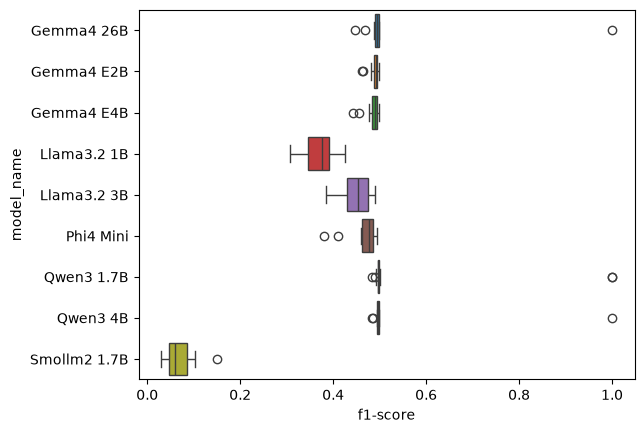

In [33]:
sns.boxplot(data=results_df[results_df["edges"] == edges].sort_values(by="model_name"), x="f1-score", y="model_name", hue="model_name")

## Arestas negativas aleatórias
- resultados semelhantes ao grupo anterior de arestas. 

In [34]:
edges = "negative_random_edges"

In [35]:
negative_random_df = results_df[results_df["edges"] == edges].groupby("model_name").agg(
    #B_params_mean = ("B_params", "mean"),
    acc_mean = ("accuracy", "mean"),
    acc_std = ("accuracy", "std"),
    prec_mean = ("precision", "mean"),
    prec_std = ("precision", "std"),
    rec_mean = ("recall", "mean"),
    rec_std = ("recall", "std"),
    f1_mean = ("f1-score", "mean"),
    f1_std = ("f1-score", "std"),
    #success_rate_mean = ("success_rate", "mean"),
).sort_values("acc_mean", ascending=False)
negative_random_df

,acc_mean,acc_std,prec_mean,prec_std,rec_mean,rec_std,f1_mean,f1_std
model_name,,,,,,,,
Qwen3 4B,0.998879,0.001310,0.766667,0.258199,0.766106,0.258819,0.766386,0.258509
Qwen3 1.7B,0.998671,0.002229,0.800000,0.253546,0.799335,0.254390,0.799667,0.253969
Gemma4 26B,0.996510,0.004090,0.666667,0.243975,0.664921,0.245258,0.665791,0.244618
Gemma4 E2B,0.990001,0.009377,0.566667,0.175933,0.561667,0.178013,0.564144,0.176970
Gemma4 E4B,0.987731,0.010210,0.600000,0.207020,0.593866,0.210233,0.596901,0.208633
Phi4 Mini,0.944987,0.042881,0.533333,0.129099,0.505827,0.138171,0.518953,0.133521
Llama3.2 3B,0.881273,0.063200,0.500000,0.000000,0.440636,0.031600,0.467878,0.018106
Llama3.2 1B,0.631785,0.090422,0.500000,0.000000,0.315892,0.045211,0.385346,0.035402
Smollm2 1.7B,0.087606,0.049740,0.500000,0.000000,0.043803,0.024870,0.078797,0.041100


<Axes: xlabel='f1-score', ylabel='model_name'>

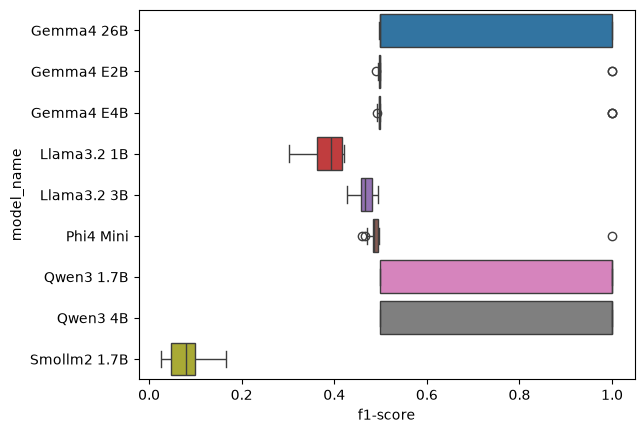

In [36]:
sns.boxplot(data=results_df[results_df["edges"] == edges].sort_values(by="model_name"), x="f1-score", y="model_name", hue="model_name")

# Visualização unificada de cada tipo de negativo

In [37]:
# TODO: temporal e random tao iguais lol
TARGET_METRIC_PREFIX = "acc"
agg_df = negative_hard_edges_df.join(negative_temporal_plausible_df, lsuffix="_similar", rsuffix="_temporal")
agg_df = agg_df.join(negative_random_df)
agg_df.rename(columns={
    f"{TARGET_METRIC_PREFIX}_mean": f"{TARGET_METRIC_PREFIX}_mean_random", 
    f"{TARGET_METRIC_PREFIX}_std": f"{TARGET_METRIC_PREFIX}_std_random"},
    inplace=True
)
target_cols = [col for col in agg_df.columns if TARGET_METRIC_PREFIX in col]
agg_df = agg_df[target_cols]
agg_df

,acc_mean_similar,acc_std_similar,acc_mean_temporal,acc_std_temporal,acc_mean_random,acc_std_random
model_name,,,,,,
Qwen3 4B,0.850084,0.047222,0.982453,0.019044,0.998879,0.001310
Qwen3 1.7B,0.849254,0.059113,0.985637,0.017761,0.998671,0.002229
Gemma4 26B,0.713764,0.106636,0.961437,0.051866,0.996510,0.004090
Gemma4 E4B,0.651618,0.100183,0.944413,0.058014,0.987731,0.010210
Gemma4 E2B,0.534974,0.130251,0.954855,0.040941,0.990001,0.009377
Phi4 Mini,0.383382,0.161642,0.880410,0.101594,0.944987,0.042881
Llama3.2 1B,0.310145,0.055519,0.589921,0.078930,0.631785,0.090422
Llama3.2 3B,0.307228,0.135346,0.815650,0.098472,0.881273,0.063200
Smollm2 1.7B,0.017985,0.012920,0.074934,0.038202,0.087606,0.049740


In [38]:
temp_accs = agg_df["acc_mean_temporal"]
rand_accs = agg_df["acc_mean_random"]
mean_diffs = (rand_accs - temp_accs).mean()
median_diffs = (rand_accs - temp_accs).median()
print(mean_diffs, median_diffs)

0.036414698764091695 0.03514588788932316


In [39]:
# facilitando a vida
inter_df = agg_df.copy()
for col in inter_df.columns:
    inter_df[col] = inter_df[col].apply(lambda x: f"{x:.3f}")

# criando tabela
inter_df = inter_df.reset_index()
table_df = pd.DataFrame()
table_df["Model"] = inter_df["model_name"]

for suffix in ["_similar", "_temporal", "_random"]:
    col_name = suffix[1:].capitalize()
    table_df[col_name] = "$" + inter_df[TARGET_METRIC_PREFIX + "_mean" + suffix]
    table_df[col_name] += " \pm "
    table_df[col_name] += inter_df[TARGET_METRIC_PREFIX + "_std" + suffix] + "$"
    
print(table_df.to_latex(index=False, column_format="lcccc"))

\begin{tabular}{lcccc}
\toprule
Model & Similar & Temporal & Random \\
\midrule
Qwen3 4B & $0.850 \pm 0.047$ & $0.982 \pm 0.019$ & $0.999 \pm 0.001$ \\
Qwen3 1.7B & $0.849 \pm 0.059$ & $0.986 \pm 0.018$ & $0.999 \pm 0.002$ \\
Gemma4 26B & $0.714 \pm 0.107$ & $0.961 \pm 0.052$ & $0.997 \pm 0.004$ \\
Gemma4 E4B & $0.652 \pm 0.100$ & $0.944 \pm 0.058$ & $0.988 \pm 0.010$ \\
Gemma4 E2B & $0.535 \pm 0.130$ & $0.955 \pm 0.041$ & $0.990 \pm 0.009$ \\
Phi4 Mini & $0.383 \pm 0.162$ & $0.880 \pm 0.102$ & $0.945 \pm 0.043$ \\
Llama3.2 1B & $0.310 \pm 0.056$ & $0.590 \pm 0.079$ & $0.632 \pm 0.090$ \\
Llama3.2 3B & $0.307 \pm 0.135$ & $0.816 \pm 0.098$ & $0.881 \pm 0.063$ \\
Smollm2 1.7B & $0.018 \pm 0.013$ & $0.075 \pm 0.038$ & $0.088 \pm 0.050$ \\
\bottomrule
\end{tabular}



# Analisando um modelo especifico

In [40]:
import numpy as np

def filter_predictions_and_labels(results: dict, labels: list, label_desc: str = None) -> tuple[np.array, np.array]:

    valid_preds = []
    valid_labels = []

    for res, label in zip(results, labels):
        if res and label_desc is None:
            if res["success"]:
                valid_preds.append(res['link'])
                valid_labels.append(label["label"])
        elif res and label_desc:
            if res["success"] and label["label_description"] == label_desc:
                valid_preds.append(res['link'])
                valid_labels.append(label["label"])
    
    print(f"Filtered predictions percentage: {len(valid_preds)}/{len(results)}")

    return np.array(valid_labels), np.array(valid_preds)

In [41]:
def find_model_and_theme(raw_results: list[dict], model: str, theme: str) -> dict | None:
    desired_results = None
    for result in raw_results:
        if result["model_name"] == model and result["theme"] == theme:
            desired_results = result
            break
    return desired_results

In [42]:
TARGET_MODEL = "gemma4_E4B"
TARGET_THEME = "economy"

In [43]:
desired_results = find_model_and_theme(raw_results, TARGET_MODEL, TARGET_THEME)

In [44]:
outputs = desired_results["results"]["outputs"]
label_infos = desired_results["labels_info"]

In [45]:
print("All edges:")
valid_labels, valid_preds = filter_predictions_and_labels(outputs, label_infos)
print(classification_report(valid_labels, valid_preds))

All edges:
Filtered predictions percentage: 5016/5023
              precision    recall  f1-score   support

       False       0.60      0.80      0.69      2510
        True       0.70      0.47      0.57      2506

    accuracy                           0.64      5016
   macro avg       0.65      0.64      0.63      5016
weighted avg       0.65      0.64      0.63      5016



# Verificando desempenho filtrando por label

In [46]:
filtered_preds, filtered_labels = filter_predictions_and_labels(outputs, label_infos, label_desc="easy true edge (above 75th percentile similarity)")
print(classification_report(filtered_labels, filtered_preds))

Filtered predictions percentage: 626/5023
              precision    recall  f1-score   support

       False       0.00      0.00      0.00       131
        True       0.79      1.00      0.88       495

    accuracy                           0.79       626
   macro avg       0.40      0.50      0.44       626
weighted avg       0.63      0.79      0.70       626



In [47]:
filtered_preds, filtered_labels = filter_predictions_and_labels(outputs, label_infos, label_desc="hard true edge (below 25th percentile similarity)")
print(classification_report(filtered_labels, filtered_preds))

Filtered predictions percentage: 627/5023
              precision    recall  f1-score   support

       False       0.00      0.00      0.00       501
        True       0.20      1.00      0.33       126

    accuracy                           0.20       627
   macro avg       0.10      0.50      0.17       627
weighted avg       0.04      0.20      0.07       627



In [48]:
filtered_preds, filtered_labels = filter_predictions_and_labels(outputs, label_infos, label_desc="hard semantic negative")
print(classification_report(filtered_labels, filtered_preds))

Filtered predictions percentage: 1004/5023
              precision    recall  f1-score   support

       False       0.58      1.00      0.73       583
        True       0.00      0.00      0.00       421

    accuracy                           0.58      1004
   macro avg       0.29      0.50      0.37      1004
weighted avg       0.34      0.58      0.43      1004



In [49]:
filtered_preds, filtered_labels = filter_predictions_and_labels(outputs, label_infos, label_desc="temporal plausible negative")
print(classification_report(filtered_labels, filtered_preds))

Filtered predictions percentage: 1003/5023
              precision    recall  f1-score   support

       False       0.92      1.00      0.96       926
        True       0.00      0.00      0.00        77

    accuracy                           0.92      1003
   macro avg       0.46      0.50      0.48      1003
weighted avg       0.85      0.92      0.89      1003



In [50]:
filtered_preds, filtered_labels = filter_predictions_and_labels(outputs, label_infos, label_desc="random negative")
print(classification_report(filtered_labels, filtered_preds))

Filtered predictions percentage: 503/5023
              precision    recall  f1-score   support

       False       0.99      1.00      1.00       499
        True       0.00      0.00      0.00         4

    accuracy                           0.99       503
   macro avg       0.50      0.50      0.50       503
weighted avg       0.98      0.99      0.99       503



# Visualizando erros do modelo

In [51]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from glm_based_event_analysis.utils.graph import get_node_metadata

In [52]:
G = graphs[TARGET_THEME]

In [53]:
# sem filtros
valid_labels, valid_preds = filter_predictions_and_labels(outputs, label_infos)

Filtered predictions percentage: 5016/5023


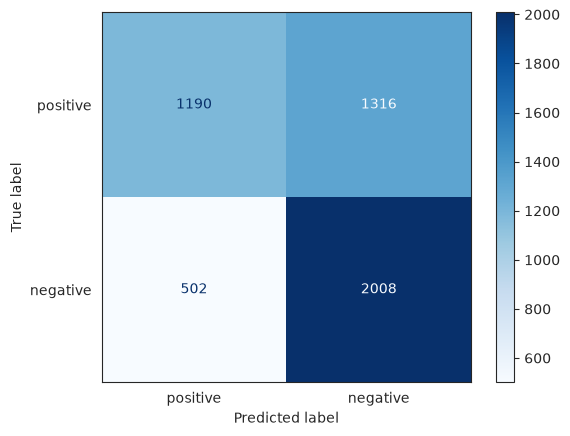

In [54]:
# mostrando matriz de confusão 
sns.set_style("white")
cm = confusion_matrix(valid_labels, valid_preds, labels=[True, False])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['positive', 'negative'])
disp.plot(cmap='Blues')

In [55]:
# filtrando informações de predição validas para as próximas analises
is_valid = [out["success"] for out in desired_results["results"]["outputs"]]
all_preds = [out["link"] for out in desired_results["results"]["outputs"]]
all_explanations = [out["explanation"] for out in desired_results["results"]["outputs"]]
all_labels = [label for label in desired_results["results"]["labels"]]
all_contexts = [context for context in desired_results["results"]["context_walks"]]
all_edge_infos = desired_results["labels_info"]

valid_preds = np.array([pred for pred, valid in zip(all_preds, is_valid) if valid])
valid_labels =np.array([label for label, valid in zip(all_labels, is_valid) if valid])
valid_explanations = [exp for exp, valid in zip(all_explanations, is_valid) if valid]
valid_contexts = [context for context, valid in zip(all_contexts, is_valid) if valid]
valid_label_info = [info for info, valid in zip(all_edge_infos, is_valid) if valid]

In [56]:
valid_label_info[0]

{'u': '3594_immigration_policy_shortages_u.s._economy_2024-11-25',
 'v': '3480_economic_crisis_shutdown_salary_2024-12-21',
 'label': True,
 'label_description': 'medium true edge (between 25th and 50th percentile similarity)',
 'semantic_similarity': 0.44580191373825073}

# Exemplos de erros
- os modelos tendem a acertar a precedencia de A sobre B, porém ignoram grandes distâncias temporais.
- maior parte dos erros vem de predizer exemplos verdadeiros como falsos. Taxa de falsos negativos alta. Provavelmente em decorrência do prompt.
- o modelo é conservador ao predizer exemplos positivos.
- há casos em que o LLM tem um racioncínio e predição de link correta que contradiz o rótulo baseado apenas em similaridade.
- na maioria das vezes em que o modelo prediz o link como falso e o rótulo é verdadeiro, o raciocínio está correto. Isto indica que a qualidade dos rótulos atrapalha na avaliação.
- curiosamente, o modelo gemma4-26B não ganha dos modelo gemma4-E4B. Minha suposição é que a qualidade dos rótulos atrapalha, já que o modelo tem uma capacidade de raciocínio maior. Logo, é esperado que as análises internas que o modelo faz irem além de simples comparações semânticas (de similaridade). Assim, é esperado que o modelo de 26B tenha uma taxa maior de falsos positivos e negativos.

In [57]:
error_mask = valid_preds != valid_labels
#error_mask = (np.array(preds) == False) & (np.array(labels) == True)
error_idxs = np.where(error_mask)[0]
sample = np.random.choice(error_idxs, size=5, replace=False)
for idx in sample:
    pred = valid_preds[idx]
    info = valid_label_info[idx]
    label = valid_labels[idx]
    context_walk = valid_contexts[idx]
    u_id = info['u']
    v_id = info['v']
    uv_sim = info["semantic_similarity"]

    u_data = get_node_metadata(G, u_id)
    v_data = get_node_metadata(G, v_id)

    print(f"Pred: {pred}, Label: {label}")
    print(f"Edge info:")
    print(f" - {u_id} -> {v_id}")
    print(f" - type: {info['label_description']}")
    print(f" - Context walk: {context_walk}")
    print(f" - Similarity: {uv_sim}")
    print(f" - Node U data: {json.dumps(u_data, indent=2)}")
    print(f" - Node V data: {json.dumps(v_data, indent=2)}")
    print(f" - Explanation: {valid_explanations[idx]}")
    print("-"*20)

Pred: False, Label: True
Edge info:
 - 3524_spain_europe_lessons_2024-12-12 -> 3472_us_borrowing_debt_greece_italy_2024-12-24
 - type: hard true edge (below 25th percentile similarity)
 - Context walk: []
 - Similarity: 0.27855098247528076
 - Node U data: {
  "what": "An analysis of the lessons that Spain can offer to the rest of Europe.",
  "where": "Spain",
  "when": "2024-12-12-08:00:00",
  "who": "The Economist",
  "how": "Through journalistic analysis and reporting on Spanish developments.",
  "why": "To explore economic or social models in Spain that could serve as examples for other European nations.",
  "event_id": "3524_spain_europe_lessons_2024-12-12"
}
 - Node V data: {
  "what": "The potential for US borrowing to eclipse the debt levels of Greece and Italy.",
  "where": "United States",
  "when": "2024-12-24-08:00:00",
  "who": "United States, Greece, and Italy",
  "how": "Through increasing government borrowing and debt accumulation.",
  "why": "Rising levels of national d

# Exemplos de acertos

In [58]:
correct_mask = valid_preds == valid_labels
correct_idxs = np.where(correct_mask)[0]
sample = np.random.choice(correct_idxs, size=5, replace=False)
for idx in sample:
    pred = valid_preds[idx]
    info = valid_label_info[idx]
    label = valid_labels[idx]
    context_walk = valid_contexts[idx]
    u_id = info['u']
    v_id = info['v']
    uv_sim = info["semantic_similarity"]

    u_data = get_node_metadata(G, u_id)
    v_data = get_node_metadata(G, v_id)

    print(f"Pred: {pred}, Label: {label}")
    print(f"Edge info:")
    print(f" - {u_id} -> {v_id}")
    print(f" - type: {info['label_description']}")
    print(f" - Context walk: {context_walk}")
    print(f" - Similarity: {uv_sim}")
    print(f" - Node U data: {json.dumps(u_data, indent=2)}")
    print(f" - Node V data: {json.dumps(v_data, indent=2)}")
    print(f" - Explanation: {valid_explanations[idx]}")
    print("-"*20)

Pred: True, Label: True
Edge info:
 - 2921_wto_trump_survival_2025-04-22 -> 2800_trump_tariffs_model_2025-05-18
 - type: easy true edge (above 75th percentile similarity)
 - Context walk: ['3004_globalization_trump_washington_post_2025-04-04', '2970_trump_bullying_globalisation_2025-04-13']
 - Similarity: 0.6044797897338867
 - Node U data: {
  "what": "Analysis of the potential impact of Trump's policies on the survival of the WTO",
  "where": "Switzerland",
  "when": "2025-04-22-07:00:00",
  "who": "World Trade Organization (WTO) and Donald Trump",
  "how": "Through political shifts and potential changes in trade policy and multilateral cooperation",
  "why": "Uncertainty regarding the future of international trade governance under Trump's administration",
  "event_id": "2921_wto_trump_survival_2025-04-22"
}
 - Node V data: {
  "what": "Analysis of the failure of Trump\u2019s tariffs and the inadequacy of the old economic model.",
  "where": "United States",
  "when": "2025-05-18-07:0

# Comparando peso de arestas de acertos e erros

In [59]:
def plot_similarity_distributions_for_label(preds, labels, infos, desired_label=True):

    correct_sims = []
    incorrect_sims = []
    for pred, label, info in zip(preds, labels, infos):

        if label != desired_label: continue
        u_id = info['u']
        v_id = info['v']
        uv_sim = info["semantic_similarity"]

        if pred == label:
            correct_sims.append(uv_sim)
        else:
            incorrect_sims.append(uv_sim)

    sns.histplot(correct_sims, color='green', label='Correct Predictions')
    sns.histplot(incorrect_sims, color='red', label='Incorrect Predictions')
    plt.legend()
    plt.title("Semantic Similarity Distributions for Correct vs Incorrect Predictions - Label: {}".format(desired_label))
    plt.xlabel("Semantic Similarity")
    plt.ylabel("Frequency")
    plt.show()

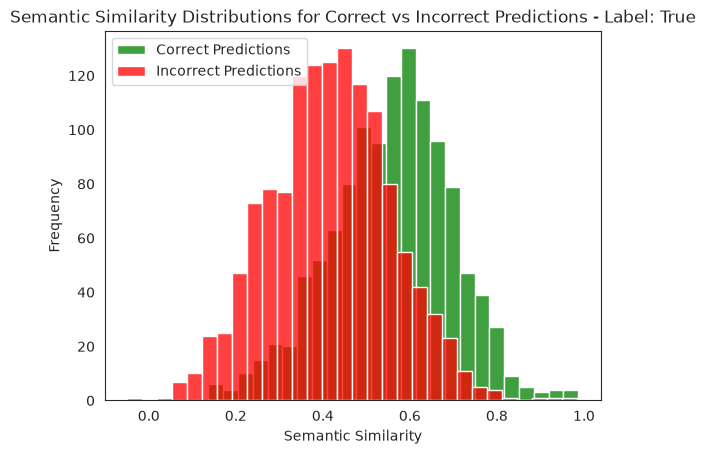

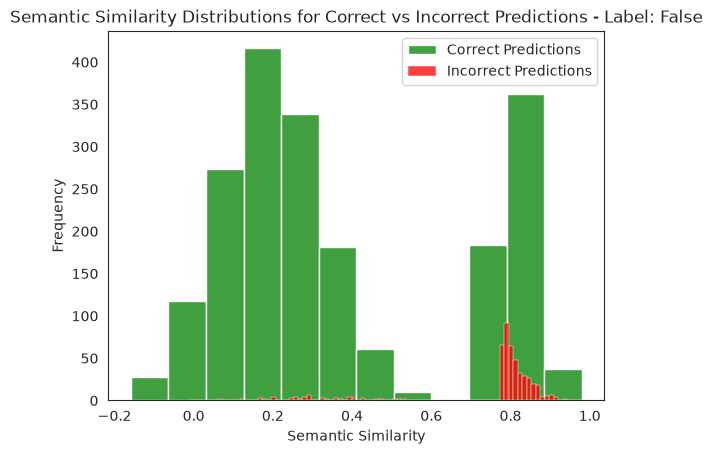

In [60]:
plot_similarity_distributions_for_label(all_preds, all_labels, all_edge_infos, desired_label=True)
plot_similarity_distributions_for_label(all_preds, all_labels, all_edge_infos, desired_label=False)

# Visualizando erros por tamanho de contexto

Complementando as análises anteriores, agora filtraremos o conjunto de arestas de teste usando o tamanho do contexto (nós predecessores) como critério. 
Para cada grafo avaliado, foram filtrados grupos de arestas com contexto 0, 1, ... max. Tendo estes grupos, foram computadas as métricas de classificação para predição de link.
- os resultados apontam que no geral, considerando predição de link usando ICL, a adição de nós predecessores (contexto adicional) não gera resultados melhores do que não usá-los para todos os modelos. Cada família de modelos tem performance diferente ao aumentar o contexto.
- há casos em que a performance (F1) piora ao adicionar o contexto (llama 3.2-3B, smollm e gemma-4).
- nos poucos casos em que houve melhora, o uso de um único evento precedente gerou os melhores ganhos (llama3.2-1B, qwen3, phi4-mini e gemma4-e2B)  

In [61]:
def plot_f1_by_context_size(df: pd.DataFrame, title: str = "F1-score by Context Size", figsize: tuple = (10, 7)):

    df = df.rename(columns={"model_name": "Model"})
    sns.set_style("whitegrid")
    plt.figure(figsize=figsize)
    sns.lineplot(data=df, x="context_size", y="f1-score", hue="Model", style="Model", markers=True, dashes=False)
    plt.title(title)
    plt.xlabel("Additional Context Size")
    plt.xticks(range(0, max(df["context_size"]) + 1))
    plt.ylabel("F1-score")

In [62]:
results_by_context_size = []
all_context_sizes = []

for res in raw_results:
    model_name = res["model_name"]
    theme = res["theme"]
    model_outputs = res["results"]
    label_info = res["labels_info"]
    all_labels = model_outputs["labels"]
    raw_outputs = model_outputs["outputs"]
    contexts = model_outputs["context_walks"]

    valid_outputs = [o for o in raw_outputs if o["success"]]
    valid_label_info = [label_info for label_info, out in zip(label_info, raw_outputs) if out["success"]]

    # obtendo o tamanho do contexto utilizado para cada predição
    context_sizes = [len(context) for context, out in zip(contexts, raw_outputs) if out["success"]]
    all_context_sizes.extend(context_sizes)

    # obtendo rotulos e predições
    valid_labels = [label_info["label"] for label_info in valid_label_info]
    preds = [out["link"] for out in valid_outputs]

    if len(context_sizes) == 0: continue
    
    # computando metricas por tamanho de contexto
    max_len = max(context_sizes)
    for length in range(0, max_len + 1):
        length_labels = [label for label, size in zip(valid_labels, context_sizes) if size == length]
        length_preds = [pred for pred, size in zip(preds, context_sizes) if size == length]

        # porcentagem do total
        percentage = len(length_labels) / len(valid_labels)

        if len(length_labels) > 0:
            report_dict = classification_report(length_labels, length_preds, output_dict=True)
        else:
            report_dict = dummy_report

        results_by_context_size.append(
            {
                "model_name": model_name,
                "B_params": model_sizes_map.get(model_name, None),
                "theme": theme,
                "context_size": length,
                "context_size_percentage": percentage,
                "accuracy": report_dict["accuracy"],
                "precision": report_dict["macro avg"]["precision"],
                "recall": report_dict["macro avg"]["recall"],
                "f1-score": report_dict["macro avg"]["f1-score"],
                "support": report_dict["macro avg"]["support"],
            }
        )
#all_context_sizes = np.array(all_context_sizes) + 1

In [63]:
context_size_df = pd.DataFrame(results_by_context_size)

# repetindo a padronação de nome
context_size_df["model_name"] = context_size_df["model_name"].apply(lambda x: " ".join([word.capitalize() for word in x.split("_")]))
context_size_df["model_name"] = context_size_df["model_name"].apply(lambda x: x[:-1] + "B" if x.endswith("b") else x) # padronizando tamanhos dos modelos


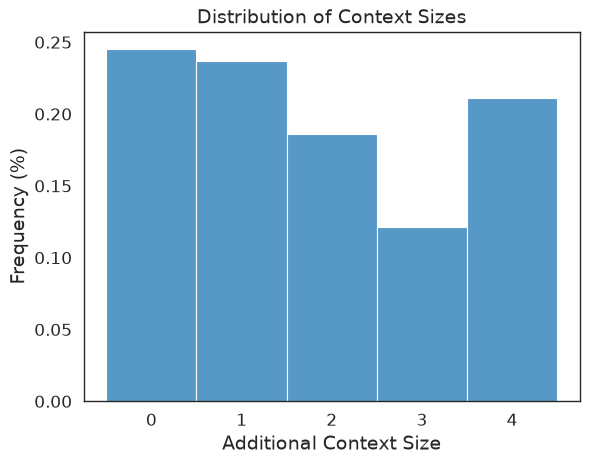

In [64]:
# visualizando distribuição de tamanhos de contexto, normalizada
sns.set_context(context="paper", font_scale=1.4)
sns.histplot(x=all_context_sizes, bins=np.arange(0, max(all_context_sizes) + 2) - 0.5, kde=False, stat="proportion")
plt.title("Distribution of Context Sizes")
plt.xlabel("Additional Context Size")
plt.ylabel("Frequency (%)")

if SAVE_FIGS:
    plt.savefig("../data/context_dist.pdf", bbox_inches='tight')

In [65]:
# desempenho geral
agg_metrics_by_context = context_size_df.groupby(["context_size", "model_name"]).agg(
    B_params_mean = ("B_params", "mean"),
    context_size_percentage_mean = ("context_size_percentage", "mean"),
    accuracy_mean = ("accuracy", "mean"),
    precision_mean = ("precision", "mean"),
    recall_mean = ("recall", "mean"),
    f1_score_mean = ("f1-score", "mean"),
    f1_score_std= ("f1-score", "std")
).sort_values(["model_name", "context_size"], ascending=True).reset_index()
agg_metrics_by_context

,context_size,model_name,B_params_mean,context_size_percentage_mean,accuracy_mean,precision_mean,recall_mean,f1_score_mean,f1_score_std
0,0,Gemma4 26B,26.0,0.253788,0.542764,0.669699,0.611694,0.518377,0.084557
1,1,Gemma4 26B,26.0,0.238752,0.638940,0.672742,0.629318,0.604434,0.082705
2,2,Gemma4 26B,26.0,0.188075,0.662330,0.673276,0.633978,0.621913,0.078673
3,3,Gemma4 26B,26.0,0.120180,0.670184,0.680532,0.649093,0.637355,0.097844
4,4,Gemma4 26B,26.0,0.199205,0.651499,0.663752,0.641296,0.621578,0.093888
5,0,Gemma4 E2B,2.0,0.253598,0.544046,0.643359,0.605977,0.527116,0.071505
6,1,Gemma4 E2B,2.0,0.238680,0.615691,0.630751,0.608082,0.589130,0.078322
7,2,Gemma4 E2B,2.0,0.188040,0.621054,0.614464,0.599517,0.591172,0.064708
8,3,Gemma4 E2B,2.0,0.120379,0.625865,0.622570,0.611412,0.605085,0.085425
9,4,Gemma4 E2B,2.0,0.199302,0.612008,0.610160,0.603277,0.591140,0.078541


In [66]:
# ordenando por tamanho
agg_metrics_by_context.sort_values(["context_size", "f1_score_mean"], ascending=[True, False])

,context_size,model_name,B_params_mean,context_size_percentage_mean,accuracy_mean,precision_mean,recall_mean,f1_score_mean,f1_score_std
25,0,Phi4 Mini,3.8,0.253521,0.559556,0.642637,0.613756,0.546793,0.067999
10,0,Gemma4 E4B,4.0,0.253375,0.562409,0.666476,0.624215,0.545614,0.074407
5,0,Gemma4 E2B,2.0,0.253598,0.544046,0.643359,0.605977,0.527116,0.071505
0,0,Gemma4 26B,26.0,0.253788,0.542764,0.669699,0.611694,0.518377,0.084557
15,0,Llama3.2 1B,1.0,0.253744,0.524499,0.609314,0.583944,0.509841,0.060181
20,0,Llama3.2 3B,3.0,0.253565,0.527802,0.638133,0.594225,0.506396,0.069710
40,0,Smollm2 1.7B,1.7,0.254104,0.611499,0.576768,0.519683,0.448895,0.025967
35,0,Qwen3 4B,4.0,0.253540,0.488237,0.650995,0.570856,0.445598,0.065988
30,0,Qwen3 1.7B,1.7,0.253547,0.460032,0.635833,0.548351,0.404679,0.046837
11,1,Gemma4 E4B,4.0,0.238544,0.648127,0.671439,0.640314,0.623460,0.074193


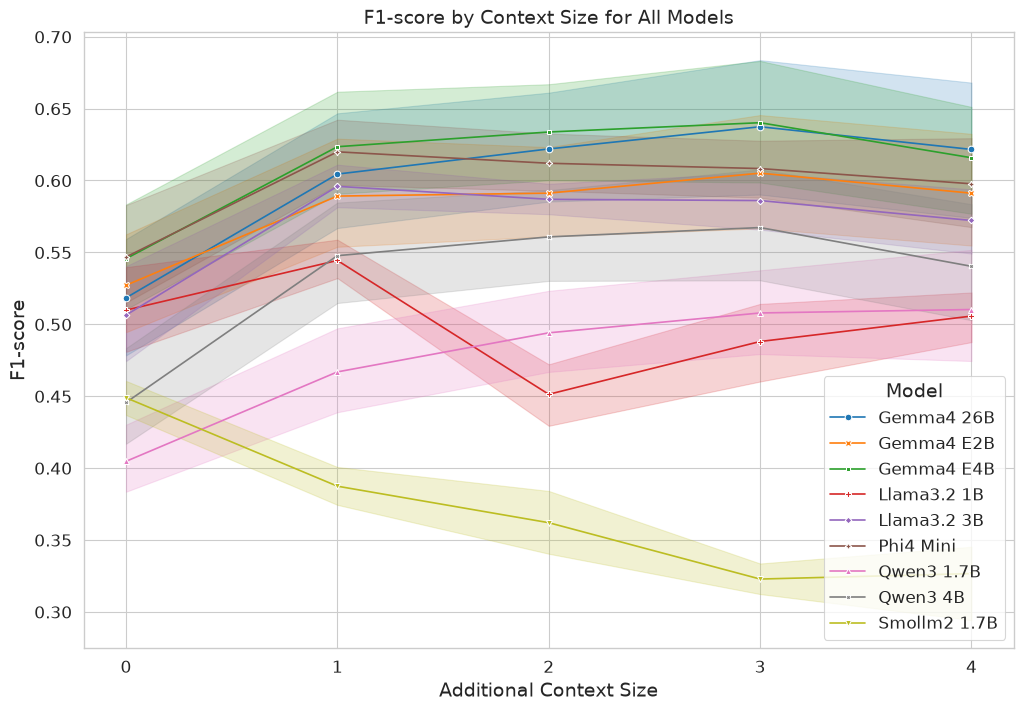

In [67]:
# visualizando desempenho por tamanho de contexto
plot_f1_by_context_size(context_size_df.sort_values(by="model_name"), title="F1-score by Context Size for All Models", figsize=(12, 8))

## Contexto para modelos Gemma 4
- Há ganho de desempenho ao considerar mais contexto. Porém, há uma saturação muito rápida.
- O maior ganho é obtido ao adicionar um único evento de contexto.
- Curiosamente, modelos maiores não batem os menores. Em alguns casos, o modelo de 2B supera modelos considerávelmente maiores.
- São os modelos com **melhor performance** no geral e com **maior desvio padrão**.

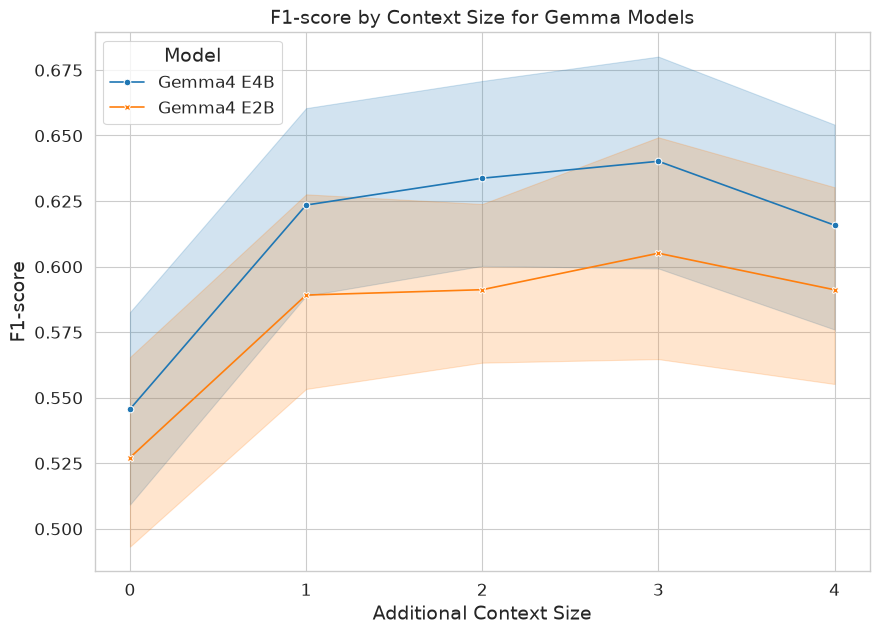

In [68]:
filter_mask = context_size_df["model_name"].str.contains("Gemma") & ~context_size_df["model_name"].str.contains("26B") # omitindo modelo de 26B
plot_f1_by_context_size(context_size_df[filter_mask].sort_values(by="model_name", ascending=False), title="F1-score by Context Size for Gemma Models", figsize=(10, 7))

if SAVE_FIGS:
    plt.savefig("../data/gemma_context.pdf", bbox_inches='tight')

## Contexto para modelos Llama 3.2
- O modelo maior usa o contexto mais efetivamente. Novamente, saturação rápida, com maior ganho ao adicionar um único evento.
- Visível degradação da performance ao avaliar contextos maiores. Mais evidente para o modelo menor.

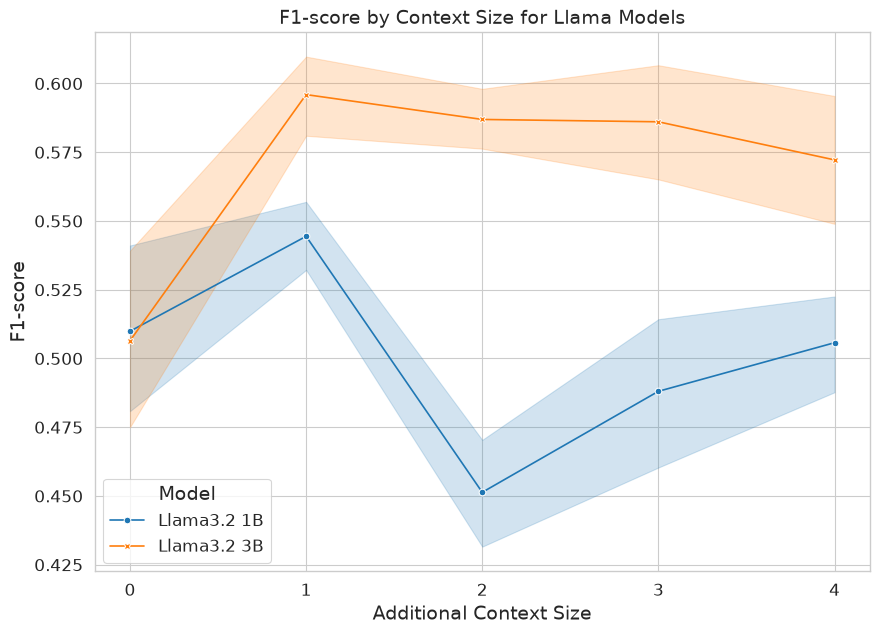

In [69]:
filter_mask = context_size_df["model_name"].str.contains("Llama")
plot_f1_by_context_size(context_size_df[filter_mask].sort_values(by="model_name"), title="F1-score by Context Size for Llama Models", figsize=(10, 7))

if SAVE_FIGS:
    plt.savefig("../data/llama_context.pdf", bbox_inches='tight')

## Contexto para modelos Qwen 3
- Similar aos modelos gemma. A adição de contexto traz ganho na performance, porém com saturação rápida.


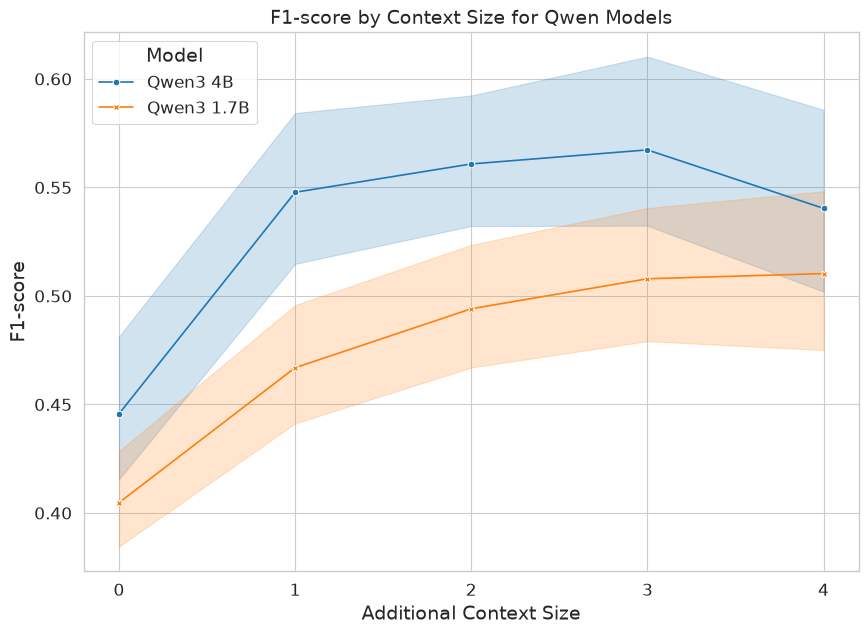

In [70]:
filter_mask = context_size_df["model_name"].str.contains("Qwen")
plot_f1_by_context_size(context_size_df[filter_mask].sort_values(by="model_name", ascending=False), title="F1-score by Context Size for Qwen Models", figsize=(10, 7))

if SAVE_FIGS:
    plt.savefig("../data/qwen_context.pdf", bbox_inches='tight')

## Contexto para outros modelos
- Phi4 teve uma performance praticamente estável para todos os contextos avaliados. Pequeno ganho para adicionar um único evento de contexto.
- O modelo Smollm2 degradou sua performance com contexto adicional.

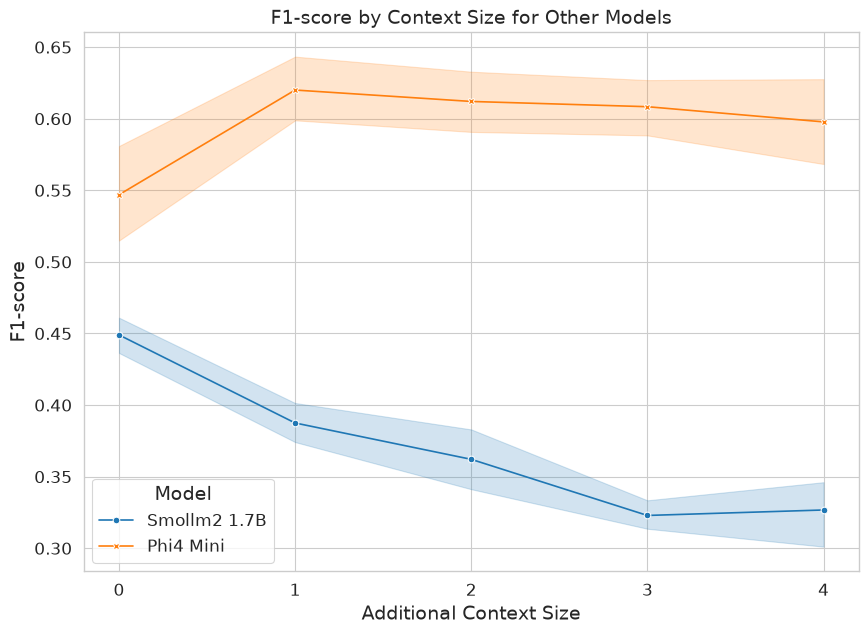

In [71]:
phi = context_size_df["model_name"].str.contains("Phi")
smol = context_size_df["model_name"].str.contains("Smol")
plot_f1_by_context_size(context_size_df[phi | smol], title="F1-score by Context Size for Other Models", figsize=(10, 7))

if SAVE_FIGS:
    plt.savefig("../data/other_context.pdf", bbox_inches='tight')

# Comparando saidas de dois modelos

In [72]:
results_df.theme.unique()

array(['conflict', 'society', 'labour', 'weather', 'science', 'politics',
       'crime', 'economy', 'transport', 'cybersecurity', 'education',
       'disaster', 'health', 'environment', 'energy'], dtype=object)

In [73]:
THEME = "weather"
MODEL1 = "gemma4_E4B"
MODEL2 = "gemma4_26B"
G = graphs[THEME]

In [74]:
res_model1 = find_model_and_theme(raw_results, MODEL1, THEME)
res_model2 = find_model_and_theme(raw_results, MODEL2, THEME)

In [75]:
outputs1 = res_model1["results"]["outputs"]
outputs2 = res_model2["results"]["outputs"]
all_contexts = res_model1["results"]["context_walks"]
both_valid = [o1["success"] and o2["success"] for o1, o2 in zip(outputs1, outputs2)]
both_valid_labels = [label_info["label"] for label_info, valid in zip(res_model1["labels_info"], both_valid) if valid]
both_valid_us = [label_info["u"] for label_info, valid in zip(res_model1["labels_info"], both_valid) if valid]
both_valid_vs = [label_info["v"] for label_info, valid in zip(res_model1["labels_info"], both_valid) if valid]
both_valid_contexts = [context for context, valid in zip(all_contexts, both_valid) if valid]
model1_preds = [o1["link"] for o1, valid in zip(outputs1, both_valid) if valid]
model2_preds = [o2["link"] for o2, valid in zip(outputs2, both_valid) if valid]
model1_explanations = [o1["explanation"] for o1, valid in zip(outputs1, both_valid) if valid]
model2_explanations = [o2["explanation"] for o2, valid in zip(outputs2, both_valid) if valid]

comparisson_df = pd.DataFrame({
    "label": both_valid_labels,
    "u": both_valid_us,
    "v": both_valid_vs,
    "context": both_valid_contexts,
    f"{MODEL1}_pred": model1_preds,
    f"{MODEL2}_pred": model2_preds, 
    f"{MODEL1}_explanation": model1_explanations,
    f"{MODEL2}_explanation": model2_explanations,
})

In [76]:
len(comparisson_df)

2869

In [77]:
# validando a criação
# é normal variar dos resultados anteriores -> estamos filtrando exemplos em que os dois modelos geram predições validas.
print(f"Model 1 ({MODEL1}) correct predictions: {sum(comparisson_df[f'{MODEL1}_pred'] == comparisson_df['label']) / len(comparisson_df):.3f}")
print(f"Model 2 ({MODEL2}) correct predictions: {sum(comparisson_df[f'{MODEL2}_pred'] == comparisson_df['label']) / len(comparisson_df):.3f}")

Model 1 (gemma4_E4B) correct predictions: 0.708
Model 2 (gemma4_26B) correct predictions: 0.707


In [78]:
# verificando quando o modelo 1 acerta e o modelo 2 discorda
model1_correct_mask = comparisson_df[f"{MODEL1}_pred"] == comparisson_df["label"]
model2_disagrees_mask = comparisson_df[f"{MODEL1}_pred"] != comparisson_df[f"{MODEL2}_pred"]
disagree_mask = model1_correct_mask & model2_disagrees_mask
disagree_df = comparisson_df[disagree_mask]
len(disagree_df)

186

In [79]:
# os modelos discordam mais nos exemplos falsos 
disagree_df["label"].value_counts(normalize=True)

label
True     0.774194
False    0.225806
Name: proportion, dtype: float64

In [80]:
# amostrando e visualizando
N_SAMPLES = 5
for _, row in disagree_df.sample(n=N_SAMPLES).iterrows():
    u_id = row["u"]
    v_id = row["v"]
    context_walk = row["context"]
    model1_pred = row[f"{MODEL1}_pred"]
    model2_pred = row[f"{MODEL2}_pred"]
    model1_explanation = row[f"{MODEL1}_explanation"]
    model2_explanation = row[f"{MODEL2}_explanation"]

    u_data = get_node_metadata(G, u_id)
    v_data = get_node_metadata(G, v_id)

    print(f"Edge: {u_id} -> {v_id}")
    print(f"Context walk:")
    for i, node in enumerate(context_walk):
        print(f"\t {i+1} - {get_node_metadata(G, node)["what"]}")
    print(f"Node A data: {json.dumps(u_data, indent=2)}")
    print(f"Node B data: {json.dumps(v_data, indent=2)}")
    print(f"Model 1 ({MODEL1}) prediction: {model1_pred}, Explanation: {model1_explanation}")
    print(f"Model 2 ({MODEL2}) prediction: {model2_pred}, Explanation: {model2_explanation}")
    print("-"*40)

Edge: 1462_weather_control_conspiracy_theory_mit_technology_review_2025-10-30 -> 1452_weather_claims_climate_change_bad_faith_2025-11-03
Context walk:
Node A data: {
  "what": "An analysis of the difficulties in debunking weather control conspiracy theories.",
  "where": "United States",
  "when": "2025-10-30-07:00:00",
  "who": "MIT Technology Review",
  "how": "Through an investigative report examining why these theories are so hard to bust.",
  "why": "To explore the complexity and persistence of weather control conspiracy theories.",
  "event_id": "1462_weather_control_conspiracy_theory_mit_technology_review_2025-10-30"
}
Node B data: {
  "what": "Discussion on weather claims and bad faith practices in the context of climate change.",
  "where": "United States",
  "when": "2025-11-03-08:00:00",
  "who": "Claims Journal",
  "how": "Through an analysis of insurance claims and legal/ethical implications in the face of climate change.",
  "why": "To address the challenges of weather-re

TODO: validar estas comparações novamente.
- os modelos discordam mais no rótulo positivo. Ou seja, quando o modelo de 4B prediz um exemplo como positivo, o modelo maior prediz como negativo.
- aparentemente o modelo maior erra mais a questão do evento B anteceder o A. O modelo de 4B em alguns casos até reconhece que A precisa anteceder B nas explicações.
- o modelo menor da sinais de que descarta relações entre eventos muito distântes temporalmente sem ser instruído diretamente para isso (grafo "society")
- por outro lado, o modelo maior aparentemente assume que não há restrições temporais para as relações.
- o maior modelo (26B) parece impor mais seus vieses. Ignora grandes distâncias temporais, assume que se os atores são iguais há relação, justifica mencionando comportamentos que espera de um grafo de eventos ("in event graphs ..."), etc.
- 

# Testes de hipótese

In [81]:
from scipy.stats import friedmanchisquare
from labicompare.core.data import EvaluationData
from labicompare.stats.posthoc import wilcoxon_holm
from labicompare.plots.ranking import plot_cd_diagram

In [82]:
# ordenandoo df para consistencia
all_edges_df = all_edges_df.sort_values(by=["theme", "model_name"])

In [83]:
METRIC = "f1-score"
#METRIC = "precision"
NULL_THRESHOLD = 0.05
model_metrics_map = {model: all_edges_df[all_edges_df["model_name"] == model][METRIC].values for model in all_edges_df["model_name"].unique()}

In [84]:
eval_df = pd.DataFrame.from_dict(model_metrics_map)
eval_df

,Gemma4 26B,Gemma4 E2B,Gemma4 E4B,Llama3.2 1B,Llama3.2 3B,Phi4 Mini,Qwen3 1.7B,Qwen3 4B,Smollm2 1.7B
0,0.654419,0.605065,0.656322,0.549875,0.605136,0.619637,0.495609,0.561666,0.385734
1,0.489115,0.481002,0.520447,0.508859,0.551363,0.535292,0.415634,0.445235,0.405925
2,0.631232,0.626503,0.668807,0.555619,0.586939,0.621299,0.484354,0.559958,0.354598
3,0.533014,0.518604,0.525393,0.566329,0.575752,0.581549,0.416715,0.475624,0.430823
4,0.601286,0.577882,0.627658,0.525941,0.569280,0.601671,0.459195,0.525503,0.387171
5,0.497127,0.500612,0.525843,0.491271,0.517371,0.531441,0.421611,0.454612,0.377315
6,0.596682,0.578232,0.606134,0.522596,0.561284,0.579066,0.469431,0.524151,0.371030
7,0.576801,0.575302,0.612664,0.498899,0.559666,0.588268,0.465013,0.514104,0.361510
8,0.647103,0.592977,0.607429,0.531131,0.612353,0.653893,0.466658,0.530879,0.376836
9,0.779045,0.738825,0.753557,0.503673,0.627746,0.696282,0.611888,0.709424,0.351296


In [85]:
# removendo o modelo de 26B
eval_df.drop(columns="Gemma4 26B", inplace=True)

In [86]:
results, pval = friedmanchisquare(*model_metrics_map.values()) 
print(f"- p-value = {pval}. Reject null hypothesis: {pval < NULL_THRESHOLD}")

- p-value = 1.5860058489233904e-17. Reject null hypothesis: True


In [87]:
# repetindo para lib labic
eval_data = EvaluationData(eval_df, higher_is_better=True)
summary = wilcoxon_holm(eval_data, alpha=NULL_THRESHOLD)
print(summary)

ComparisonSummary(Friedman P-Value=0.0000, H0=REJECTED, Models=8)


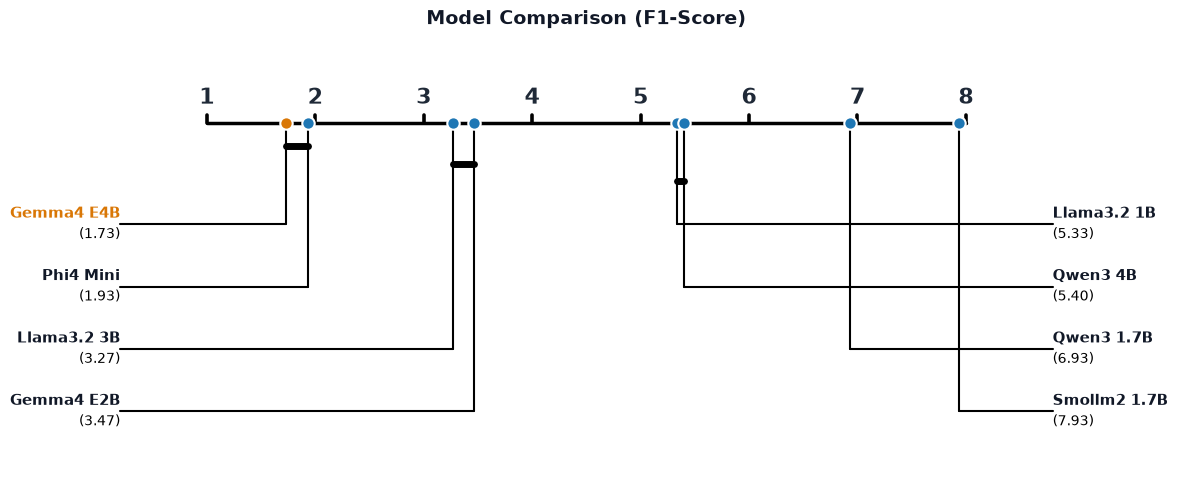

In [88]:
# diferença critica
fig = plot_cd_diagram(
    data=eval_data,
    summary=summary,
    title="Model Comparison (F1-Score)",
    highlight_models=['Gemma4 E4B'],
    highlight_color='#d97706' # Optional custom color (Default: Amber/Orange)
)
plt.savefig("../data/cd_diagram.pdf", bbox_inches="tight")

In [89]:
summary.get_leaderboard()

,Mean_Performance,Rank
Gemma4 E4B,0.607148,1
Phi4 Mini,0.595995,2
Gemma4 E2B,0.576933,3
Llama3.2 3B,0.570432,4
Qwen3 4B,0.525046,5
Llama3.2 1B,0.521016,6
Qwen3 1.7B,0.470535,7
Smollm2 1.7B,0.380480,8
